# Simple Cardio Ontology Explorer

This notebook provides easy access to the most important information from the cardiovascular ontology.

**Quick Start:**
1. Set the ontology path below
2. Run all cells
3. Use the search function to find concepts
4. View statistics and top classes/properties

In [22]:
# Configuration: Set your ontology path
ONTOLOGY_PATH = '/prj/doctoral_letters/guide/data/ontologies/cardio_ontology_class.owl'

# Import libraries
import rdflib
import pandas as pd
from rdflib.namespace import RDF, RDFS, OWL, SKOS
from pathlib import Path
import matplotlib.pyplot as plt

# Import SNOMED explorer for resolving concept names
from cardio_graph.snomedct_utils.snomed_query import SnomedExplorer

# Load ontology
print(f"Loading ontology from: {ONTOLOGY_PATH}")
g = rdflib.Graph()
g.parse(ONTOLOGY_PATH)
print(f"✅ Loaded {len(g):,} triples")

# Connect to SNOMED database for concept name resolution
print("Connecting to SNOMED database...")
snomed_explorer = SnomedExplorer()
try:
    snomed_explorer.connect()
    print("✅ Connected to SNOMED database")
except Exception as e:
    print(f"⚠️  Could not connect to SNOMED database: {e}")
    print("Continuing without SNOMED name resolution...")
    snomed_explorer = None

Loading ontology from: /prj/doctoral_letters/guide/data/ontologies/cardio_ontology_class.owl
✅ Loaded 80,892 triples
Connecting to SNOMED database...
Connected to snomed database on snomed-ct2.internal
✅ Connected to SNOMED database
✅ Loaded 80,892 triples
Connecting to SNOMED database...
Connected to snomed database on snomed-ct2.internal
✅ Connected to SNOMED database


## 📊 Basic Statistics

In [7]:
# Count different types of entities
classes = set(g.subjects(RDF.type, OWL.Class))
individuals = set(g.subjects(RDF.type, OWL.NamedIndividual))
object_props = set(g.subjects(RDF.type, OWL.ObjectProperty))
data_props = set(g.subjects(RDF.type, OWL.DatatypeProperty))

print("📊 Ontology Statistics:")
print(f"• Classes: {len(classes):,}")
print(f"• Individuals: {len(individuals):,}")
print(f"• Object Properties: {len(object_props):,}")
print(f"• Data Properties: {len(data_props):,}")
print(f"• Total Triples: {len(g):,}")

📊 Ontology Statistics:
• Classes: 21,350
• Individuals: 0
• Object Properties: 89
• Data Properties: 13
• Total Triples: 80,892


## 🔍 Search Function

In [8]:
def search_ontology(query, limit=10):
    """Search for classes and individuals by name"""
    query = query.lower()
    results = []
    
    # Search classes
    for cls in classes:
        labels = [str(o) for o in g.objects(cls, RDFS.label)]
        synonyms = [str(o) for o in g.objects(cls, SKOS.altLabel)]
        all_text = ' '.join(labels + synonyms).lower()
        
        if query in all_text:
            results.append({
                'type': 'Class',
                'label': labels[0] if labels else str(cls).split('/')[-1],
                'uri': str(cls)
            })
    
    # Search individuals
    for ind in individuals:
        labels = [str(o) for o in g.objects(ind, RDFS.label)]
        synonyms = [str(o) for o in g.objects(ind, SKOS.altLabel)]
        all_text = ' '.join(labels + synonyms).lower()
        
        if query in all_text:
            results.append({
                'type': 'Individual',
                'label': labels[0] if labels else str(ind).split('/')[-1],
                'uri': str(ind)
            })
    
    return pd.DataFrame(results[:limit])

# Example usage
print("🔍 Search Examples:")
search_ontology("heart")

🔍 Search Examples:


,type,label,uri
0,Class,Framingham coronary heart disease 10 year risk...,http://snomed.info/id/315039001
1,Class,Fetal heart failure (disorder),http://snomed.info/id/462172006
2,Class,Heart valve disorder,http://snomed.info/id/368009
3,Class,New York Heart Association classification of h...,http://snomed.info/id/366743000
4,Class,H/O: Heart failure in last year (situation),http://snomed.info/id/138789008
5,Class,Red half-moon nail in congestive heart failure...,http://snomed.info/id/403298007
6,Class,"X-linked intellectual disability, cardiomegaly...",http://snomed.info/id/773587008
7,Class,FH: Ischaemic heart disease >60 (& [myocardial...,http://snomed.info/id/160359006
8,Class,Suspected heart failure (situation),http://snomed.info/id/393692001
9,Class,Chronic congestive heart failure (disorder),http://snomed.info/id/195110006


## 📈 Top Classes by Subclass Count

In [10]:
# Get class hierarchy information (subclasses of each class)
class_hierarchy = []
for cls in classes:
    # Count direct subclasses
    subclass_count = len(list(g.subjects(RDFS.subClassOf, cls)))
    
    # Get label
    labels = list(g.objects(cls, RDFS.label))
    label = str(labels[0]) if labels else str(cls).split('/')[-1]
    
    class_hierarchy.append({
        'class': label,
        'subclass_count': subclass_count,
        'uri': str(cls)
    })

# Sort and display top classes by subclass count
classes_df = pd.DataFrame(class_hierarchy).sort_values('subclass_count', ascending=False)
classes_df.head(10)

,class,subclass_count,uri
10906,ClinicalAction,1390,http://dieterich-lab.org/ontologies/cardioguid...
7600,PatientPhenotype,1365,http://dieterich-lab.org/ontologies/cardioguid...
19651,Condition,832,http://dieterich-lab.org/ontologies/cardioguid...
18165,Medication,736,http://dieterich-lab.org/ontologies/cardioguid...
9550,EvidenceSource,122,http://dieterich-lab.org/ontologies/cardioguid...
14508,Purpose,117,http://dieterich-lab.org/ontologies/cardioguid...
6510,WorkflowStep,25,http://dieterich-lab.org/ontologies/cardioguid...
1489,GuidelineSource,4,http://dieterich-lab.org/ontologies/cardioguid...
19583,ClinicalWorkflow,3,http://dieterich-lab.org/ontologies/cardioguid...
13673,EvidenceStatement,2,http://dieterich-lab.org/ontologies/cardioguid...


## 🔗 Top Properties by Usage

In [23]:
def get_readable_label(g, uri):
    """Get a human-readable label for a URI, handling SNOMED concepts specially"""
    if not isinstance(uri, rdflib.URIRef):
        return str(uri)
    
    # Check if this is a SNOMED URI
    uri_str = str(uri)
    if 'snomed.info/id/' in uri_str:
        snomed_id = uri_str.split('/')[-1]
        try:
            snomed_id_int = int(snomed_id)
            if snomed_explorer:
                term = snomed_explorer.get_preferred_term(snomed_id_int)
                if term:
                    return term
        except (ValueError, Exception):
            pass
        # Fallback if lookup fails
        return f"SNOMED:{snomed_id}"
    
    # Try rdfs:label first
    rdfs_labels = list(g.objects(uri, RDFS.label))
    if rdfs_labels:
        label = str(rdfs_labels[0])
        # If it's a generic SNOMED label, we already handled it above
        if label.startswith('SNOMED Concept '):
            # This shouldn't happen for SNOMED URIs, but just in case
            return label
        else:
            # It's a meaningful label
            return label
    
    # Try SKOS altLabel
    skos_labels = list(g.objects(uri, SKOS.altLabel))
    if skos_labels:
        return str(skos_labels[0])
    
    # Fallback to URI fragment
    return str(uri).split('/')[-1] or str(uri).split('#')[-1]

# Count property usage and collect examples
property_usage = {}
for prop in object_props | data_props:
    count = len(list(g.triples((None, prop, None))))
    labels = list(g.objects(prop, RDFS.label))
    label = str(labels[0]) if labels else str(prop).split('#')[-1]
    
    # Get one example triple for this property
    example_triple = None
    for s, p, o in g.triples((None, prop, None)):
        # Get readable labels for subject and object if possible
        s_label = get_readable_label(g, s)
        o_label = get_readable_label(g, o) if isinstance(o, rdflib.URIRef) else str(o)
        
        example_triple = f"{s_label} → {o_label}"
        break  # Just need one example
    
    property_usage[label] = {
        'usage': count,
        'example': example_triple
    }

# Sort and display top properties
props_data = []
for prop_name, data in property_usage.items():
    props_data.append({
        'property': prop_name,
        'usage': data['usage'],
        'example': data['example']
    })

props_df = pd.DataFrame(props_data).sort_values('usage', ascending=False)

# Display with custom formatting to show examples
print("🔗 Top Properties by Usage (with examples):")
for idx, row in props_df.head(10).iterrows():
    print(f"• {row['property']}: {row['usage']:,} uses")
    print(f"  Example: {row['example']}")
    print()

🔗 Top Properties by Usage (with examples):
• Is a (attribute): 12,594 uses
  Example: Family history of leukemia (situation) → Family history of malignant hematopoietic neoplasm (situation)

• Method (attribute): 5,176 uses
  Example: Culture typing procedure, serologic method, agglutination grouping (procedure) → Evaluation - action (qualifier value)

• Finding site: 1,233 uses
  Example: Acute ST segment elevation myocardial infarction (disorder) → Myocardium structure (body structure)

• Interprets: 1,145 uses
  Example: Acute ST segment elevation myocardial infarction (disorder) → ST segment (observable entity)

• Due to: 877 uses
  Example: Renal hypertension complicating pregnancy, childbirth and the puerperium (disorder) → Kidney disease (disorder)

• Associated morphology (attribute): 592 uses
  Example: Acute ST segment elevation myocardial infarction (disorder) → Acute infarct (morphologic abnormality)

• Has interpretation: 557 uses
  Example: Acute ST segment elevation myoc

## 📊 Quick Visualizations

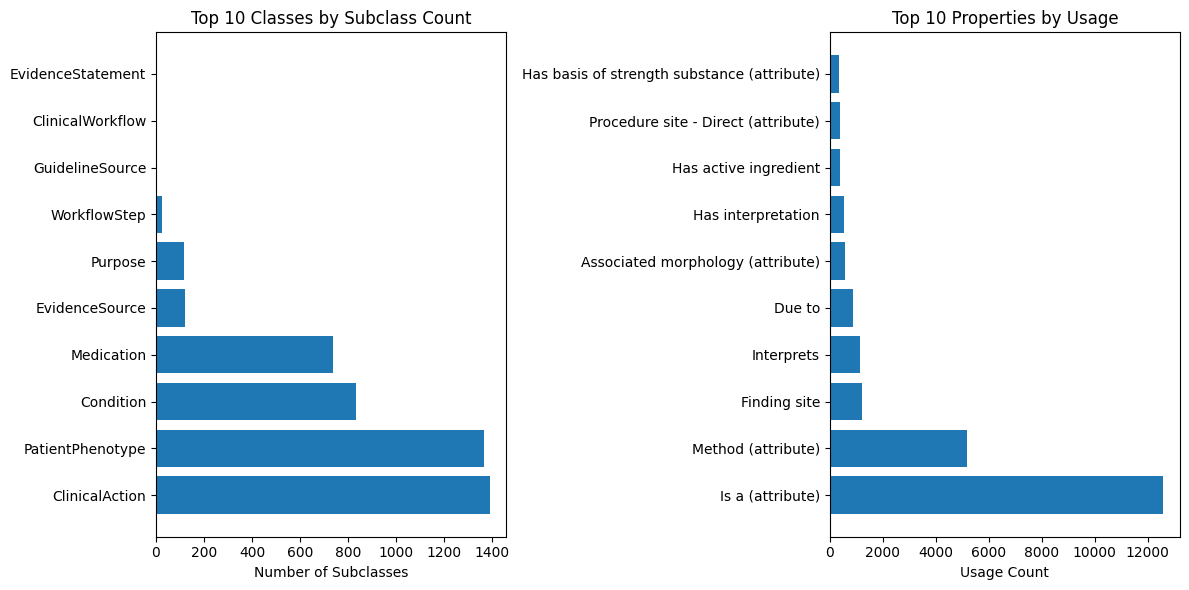

In [17]:
# Plot top classes by subclass count
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
top_classes = classes_df.head(10)
plt.barh(top_classes['class'], top_classes['subclass_count'])
plt.title('Top 10 Classes by Subclass Count')
plt.xlabel('Number of Subclasses')

# Plot top properties by usage
plt.subplot(1, 2, 2)
top_props = props_df.head(10)
plt.barh(top_props['property'], top_props['usage'])
plt.title('Top 10 Properties by Usage')
plt.xlabel('Usage Count')

plt.tight_layout()
plt.show()

## 🎯 How to Use This Notebook

### Basic Usage:
1. **Set the ontology path** at the top of the notebook
2. **Run all cells** to load and analyze the ontology
3. **Use the search function** to find specific concepts:
   ```python
   search_ontology("diabetes")  # Search for concepts containing "diabetes"
   ```

### Available Functions:
- `search_ontology(query, limit=10)` - Search classes and individuals by name
- `classes_df` - DataFrame with all classes and their subclass counts
- `props_df` - DataFrame with all properties, usage counts, and examples

### Example Queries:
```python
# Find heart-related concepts
search_ontology("heart")

# Find medication concepts
search_ontology("medication")

# Find condition concepts
search_ontology("condition")
```

### DataFrames Available:
- `classes_df`: All classes with subclass counts
- `props_df`: All properties with usage counts and examples

Filter them like any pandas DataFrame:
```python
# Classes with more than 10 subclasses
classes_df[classes_df.subclass_count > 10]

# Properties used more than 1000 times
props_df[props_df.usage > 1000]
```

# Cleanup
if snomed_explorer:
    snomed_explorer.disconnect()
    print("✅ SNOMED database connection closed")